In [9]:
import pandas as pd

# Import cleaned CSV files
orders_cl = pd.read_csv("../Data/cleaned/orders_cl.csv")
orderlines_cl = pd.read_csv("../Data/cleaned/orderlines_cl.csv")
products_cl = pd.read_csv("../Data/cleaned/products_cl.csv")
brands_cl = pd.read_csv("../Data/cleaned/brands_cl.csv")
orderlines_qu = pd.read_csv("../Data/cleaned/orderlines_qu.csv")
orders_qu = pd.read_csv("../Data/cleaned/orders_qu.csv")
# Correct data types
orderlines_qu['date'] = pd.to_datetime(orderlines_qu['date'])
orders_qu['created_date'] = pd.to_datetime(orders_qu['created_date'])
# Incorporating additional information into orderlines data frame
orderlines_qu['short'] = orderlines_qu['sku'].str[:3]
orderlines_expanded = (
    orderlines_qu
    .merge(products_cl, on='sku')
    .merge(brands_cl, on='short')
    .rename(columns={'long': 'brand'})
    .drop(columns=['short'])
)
# Creating composite columns
orderlines_expanded['revenue'] = (
    orderlines_expanded['unit_price'] * orderlines_expanded['product_quantity']
)
orderlines_expanded['discount'] = (
    orderlines_expanded['price'] - orderlines_expanded['unit_price']
)
orderlines_expanded['total_discount'] = (
    orderlines_expanded['discount'] * orderlines_expanded['product_quantity']
)
orderlines_expanded['percentage_discount'] = (
    100 * orderlines_expanded['discount'] / orderlines_expanded['price']
)

#### Exercise 1: Import Seaborn and use a scatterplot to see if revenue and total discount are correlated

In [10]:
orderlines_expanded

,id,id_order,product_id,product_quantity,sku,unit_price,date,name,desc,price,in_stock,type,brand,revenue,discount,total_discount,percentage_discount
0,1119116,299545,0,1,OWC0100,47.49,2017-01-01 01:46:16,OWC In-line Digital Temperature Sensor Kit HDD...,Kit temperature sensor for HDD iMac 21 inch an...,60.99,1,12755395,OWC,47.49,13.50,13.50,22.134776
1,1119119,299546,0,1,IOT0014,18.99,2017-01-01 01:50:34,iOttie Easy View 2 Car Black Support,IPhone car holder 7 plus / 7/6 Plus / 6 / 5s /...,22.95,0,5720,iOttie,18.99,3.96,3.96,17.254902
2,1119120,295347,0,1,APP0700,72.19,2017-01-01 01:54:11,Apple 85W MagSafe 2 charger MacBook Pro screen...,Apple MagSafe 2 Charger for MacBook Pro 15-inc...,89.00,1,13005399,Apple,72.19,16.81,16.81,18.887640
3,1119134,299556,0,1,CRU0039-A,60.90,2017-01-01 02:20:14,(Open) Crucial 240GB SSD 7mm BX200,SSD hard drive and high-speed performance with...,76.99,0,1298,Crucial,60.90,16.09,16.09,20.898818
4,1119145,299561,0,1,PEB0015,142.49,2017-01-01 02:38:50,Pebble Smartwatch Time Steel Black,Bluetooth Smart Watch with steel case leather ...,299.99,0,11905404,Pebble,142.49,157.50,157.50,52.501750
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53190,1649447,527035,0,1,APP0698,9.99,2018-03-14 11:42:41,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1,1230,Apple,9.99,15.01,15.01,60.040000
53191,1649512,527070,0,2,APP0698,9.99,2018-03-14 11:49:01,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1,1230,Apple,19.98,15.01,30.02,60.040000
53192,1649522,527074,0,2,APP0698,9.99,2018-03-14 11:49:36,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1,1230,Apple,19.98,15.01,30.02,60.040000
53193,1649565,527096,0,3,APP0698,9.99,2018-03-14 11:54:35,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1,1230,Apple,29.97,15.01,45.03,60.040000


In [12]:
orders_qu

,order_id,created_date,total_paid,state
0,241423,2017-11-06 13:10:02,136.15,Completed
1,242832,2017-12-31 17:40:03,15.76,Completed
2,243330,2017-02-16 10:59:38,84.98,Completed
3,245275,2017-06-28 11:35:37,149.00,Completed
4,245595,2017-01-21 12:52:47,112.97,Completed
...,...,...,...,...
40980,527042,2018-03-14 11:47:50,18.98,Completed
40981,527070,2018-03-14 11:50:48,24.97,Completed
40982,527074,2018-03-14 11:51:42,24.97,Completed
40983,527096,2018-03-14 11:58:40,34.96,Completed


#### Exercise 2: Use Seaborn to plot the total discounted each month as a line plot

In [13]:
orderlines_expanded["month"] = orderlines_expanded["date"].dt.to_period("M")

In [17]:
monthly_discount["month"] = monthly_discount["month"].astype(str)

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

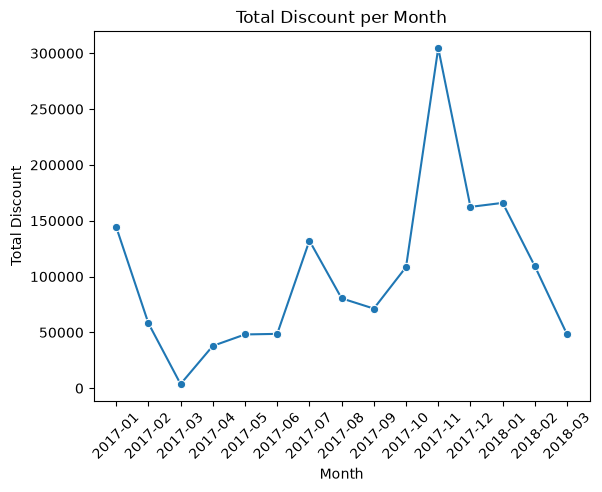

In [18]:
sns.lineplot(
    data=monthly_discount,
    x="month",
    y="total_discount",
    marker="o"
)

plt.xticks(rotation=45)
plt.title("Total Discount per Month")
plt.xlabel("Month")
plt.ylabel("Total Discount")
plt.show()

In [19]:
monthly_discount["total_discount"] = pd.to_numeric(
    monthly_discount["total_discount"],
    errors="coerce"
)

#### Exercise 3: Use seaborn to plot a scatterplot visualizing the relationship between the total quantity sold and the average percentage discount for each product<br>
(To simplify this exercise, you don't need to take into account `'product_quantity'` in the average discount percentage)

In [20]:
product_summary = (
    orderlines_expanded
    .groupby("sku")
    .agg(
        total_quantity=("product_quantity", "sum"),
        avg_percentage_discount=("percentage_discount", "mean")
    )
    .reset_index()
)

In [21]:
product_summary.info()

<class 'pandas.DataFrame'>
RangeIndex: 5079 entries, 0 to 5078
Data columns (total 3 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   sku                      5079 non-null   str    
 1   total_quantity           5079 non-null   int64  
 2   avg_percentage_discount  5079 non-null   float64
dtypes: float64(1), int64(1), str(1)
memory usage: 119.2 KB


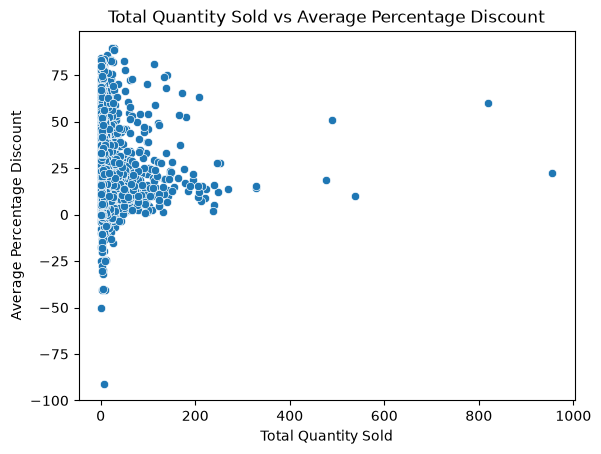

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    data=product_summary,
    x="total_quantity",
    y="avg_percentage_discount"
)

plt.title("Total Quantity Sold vs Average Percentage Discount")
plt.xlabel("Total Quantity Sold")
plt.ylabel("Average Percentage Discount")
plt.show()

#### Exercise 4: Use Seaborn to plot the quantity of iPhone cases sold as a line plot

In [24]:
iphone_cases = products_cl[
    products_cl["name"].str.contains(
        "iphone.*case|case.*iphone",
        case=False,
        na=False
    )
]

In [25]:
iphone_orderlines = orderlines_expanded[
    orderlines_expanded["sku"].isin(iphone_cases["sku"])
]

In [26]:
daily_quantity = (
    iphone_orderlines
    .groupby("date")["product_quantity"]
    .sum()
    .reset_index()
)

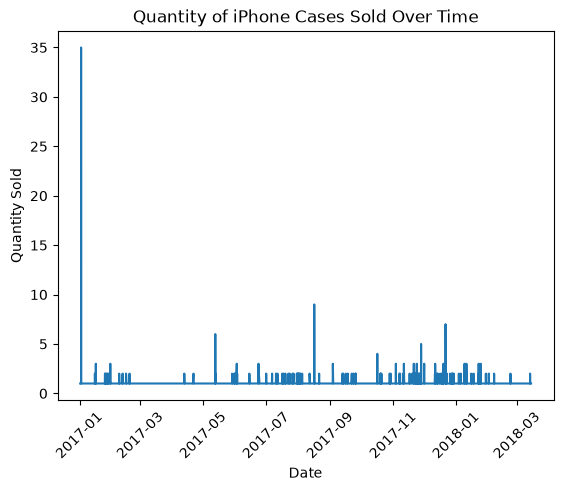

In [ ]:
sns.lineplot(
    data=daily_quantity,
    x="date",
    y="product_quantity"
)

plt.title("Quantity of iPhone Cases Sold Over Time")
plt.xlabel("Date")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=45)
plt.show()

In [29]:
products_cl.columns

Index(['sku', 'name', 'desc', 'price', 'in_stock', 'type'], dtype='str')

In [30]:
iphone_orderlines = orderlines_expanded[
    orderlines_expanded["sku"].isin(iphone_cases["sku"])
]

In [31]:
daily_quantity = (
    iphone_orderlines
    .groupby("date")["product_quantity"]
    .sum()
    .reset_index()
)

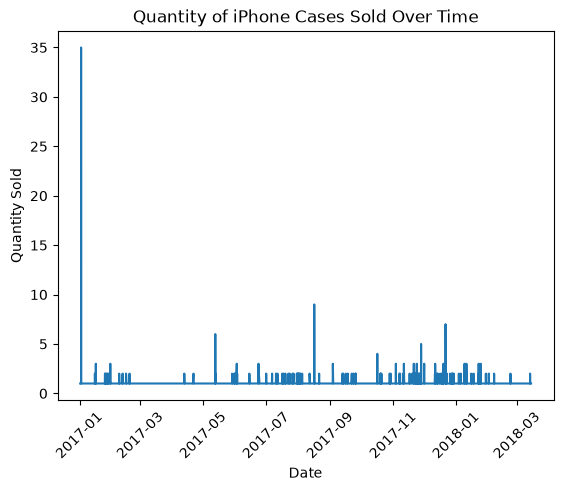

In [32]:
sns.lineplot(
    data=daily_quantity,
    x="date",
    y="product_quantity"
)

plt.title("Quantity of iPhone Cases Sold Over Time")
plt.xlabel("Date")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=45)
plt.show()

#### Exercise 5: Write a Python function that takes in a data frame and the name of a numerical column and returns a mask that could be used **to select outlier rows**<br>
Hint 1 reminds you what the rule is in statistics for determining if data is an outlier and well as the pandas function necessary to get the required numbers<br>
Hint 2 gives further guidance on how to complete the function

In [34]:
Q1 = products_cl["price"].quantile(0.25)
Q1

np.float64(42.99)

In [35]:
Q3 = products_cl["price"].quantile(0.75)
Q3

np.float64(660.6949999999999)

In [36]:
IQR = Q3 - Q1
IQR

np.float64(617.7049999999999)

In [37]:
lower_bound = Q1 - 1.5 * IQR
lower_bound

np.float64(-883.5674999999999)

In [38]:
upper_bound = Q3 + 1.5 * IQR
upper_bound

np.float64(1587.2524999999998)

In [39]:
mask = (products_cl["price"] < lower_bound) | (products_cl["price"] > upper_bound)
mask

0       False
1       False
2       False
3       False
4       False
        ...  
9987    False
9988    False
9989    False
9990    False
9991    False
Name: price, Length: 9992, dtype: bool

In [40]:
products_cl[mask]

,sku,name,desc,price,in_stock,type
100,PAC0508,Apple MacBook Pro 133 '' 25GHz | 16GB RAM | 1T...,Apple MacBook Pro Fusion Drive 16GB 2 internal...,1919.00,0,1282
101,PAC0507,Apple MacBook Pro 133 '' 25Ghz | 16GB RAM | Fu...,Apple MacBook Pro Fusion Drive 16GB 2 internal...,1639.00,0,1282
102,PAC0515,"Apple MacBook Pro 133 ""i7 29GHz | RAM 16GB | 5...",Apple MacBook Pro 133 inches (MD101Y / A) and ...,2039.00,0,1282
103,PAC0510,"Apple MacBook Pro 133 ""i7 29GHz | RAM 16GB | 7...",Apple MacBook Pro Fusion Drive 16GB 2 internal...,2039.00,0,1282
104,PAC0185,"Apple MacBook Pro 133 ""i5 25GHz | RAM 16GB | 2...",Apple MacBook Pro 133 inches (MD101Y / A) with...,1639.00,0,1282
...,...,...,...,...,...,...
9812,AP20449,"Like new - Apple Macbook Retina 12 ""Core m5 12...",Retina Display MacBook 12-inch revised and rea...,1799.00,0,"5,39E+11"
9887,DLL0053,"Dell UltraSharp UP2718Q Monitor 27 ""4K HDR",Monitor 27 inch 4K 4K and 6ms response height ...,1869.99,0,1296
9890,PAC2510,"Apple iMac 27 ""Core i5 3.3GHz Retina 5K | 16GB...",27-inch iMac 5K Retina refitted with 16GB of R...,2869.00,0,"5,74E+15"
9891,AP20461,"Apple MacBook Pro 15 ""Core i7 Touch Bar 26GHz ...",Refurbished MacBook Pro and 15-inch Apple cert...,2699.00,1,"1,02E+12"


In [41]:
def get_outlier_mask(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    mask = (df[column] < lower_bound) | (df[column] > upper_bound)
    
    return mask

In [42]:
mask = get_outlier_mask(products_cl, "price")

In [43]:
products_cl[mask]

,sku,name,desc,price,in_stock,type
100,PAC0508,Apple MacBook Pro 133 '' 25GHz | 16GB RAM | 1T...,Apple MacBook Pro Fusion Drive 16GB 2 internal...,1919.00,0,1282
101,PAC0507,Apple MacBook Pro 133 '' 25Ghz | 16GB RAM | Fu...,Apple MacBook Pro Fusion Drive 16GB 2 internal...,1639.00,0,1282
102,PAC0515,"Apple MacBook Pro 133 ""i7 29GHz | RAM 16GB | 5...",Apple MacBook Pro 133 inches (MD101Y / A) and ...,2039.00,0,1282
103,PAC0510,"Apple MacBook Pro 133 ""i7 29GHz | RAM 16GB | 7...",Apple MacBook Pro Fusion Drive 16GB 2 internal...,2039.00,0,1282
104,PAC0185,"Apple MacBook Pro 133 ""i5 25GHz | RAM 16GB | 2...",Apple MacBook Pro 133 inches (MD101Y / A) with...,1639.00,0,1282
...,...,...,...,...,...,...
9812,AP20449,"Like new - Apple Macbook Retina 12 ""Core m5 12...",Retina Display MacBook 12-inch revised and rea...,1799.00,0,"5,39E+11"
9887,DLL0053,"Dell UltraSharp UP2718Q Monitor 27 ""4K HDR",Monitor 27 inch 4K 4K and 6ms response height ...,1869.99,0,1296
9890,PAC2510,"Apple iMac 27 ""Core i5 3.3GHz Retina 5K | 16GB...",27-inch iMac 5K Retina refitted with 16GB of R...,2869.00,0,"5,74E+15"
9891,AP20461,"Apple MacBook Pro 15 ""Core i7 Touch Bar 26GHz ...",Refurbished MacBook Pro and 15-inch Apple cert...,2699.00,1,"1,02E+12"


#### Bonus: Use Seaborn to plot the average percentage discount and total number of **orders** daily. Plot them in separate plots, one above the other<br>
To simplify things, don't bother weighting the average percentage discount according to the quantity

In [45]:
orderlines_expanded.columns.tolist()

['id',
 'id_order',
 'product_id',
 'product_quantity',
 'sku',
 'unit_price',
 'date',
 'name',
 'desc',
 'price',
 'in_stock',
 'type',
 'brand',
 'revenue',
 'discount',
 'total_discount',
 'percentage_discount',
 'month']

In [46]:
orderlines_expanded.head()

,id,id_order,product_id,product_quantity,sku,unit_price,date,name,desc,price,in_stock,type,brand,revenue,discount,total_discount,percentage_discount,month
0,1119116,299545,0,1,OWC0100,47.49,2017-01-01 01:46:16,OWC In-line Digital Temperature Sensor Kit HDD...,Kit temperature sensor for HDD iMac 21 inch an...,60.99,1,12755395,OWC,47.49,13.50,13.50,22.134776,2017-01
1,1119119,299546,0,1,IOT0014,18.99,2017-01-01 01:50:34,iOttie Easy View 2 Car Black Support,IPhone car holder 7 plus / 7/6 Plus / 6 / 5s /...,22.95,0,5720,iOttie,18.99,3.96,3.96,17.254902,2017-01
2,1119120,295347,0,1,APP0700,72.19,2017-01-01 01:54:11,Apple 85W MagSafe 2 charger MacBook Pro screen...,Apple MagSafe 2 Charger for MacBook Pro 15-inc...,89.00,1,13005399,Apple,72.19,16.81,16.81,18.887640,2017-01
3,1119134,299556,0,1,CRU0039-A,60.90,2017-01-01 02:20:14,(Open) Crucial 240GB SSD 7mm BX200,SSD hard drive and high-speed performance with...,76.99,0,1298,Crucial,60.90,16.09,16.09,20.898818,2017-01
4,1119145,299561,0,1,PEB0015,142.49,2017-01-01 02:38:50,Pebble Smartwatch Time Steel Black,Bluetooth Smart Watch with steel case leather ...,299.99,0,11905404,Pebble,142.49,157.50,157.50,52.501750,2017-01


In [47]:
orderlines_expanded.columns.tolist()

['id',
 'id_order',
 'product_id',
 'product_quantity',
 'sku',
 'unit_price',
 'date',
 'name',
 'desc',
 'price',
 'in_stock',
 'type',
 'brand',
 'revenue',
 'discount',
 'total_discount',
 'percentage_discount',
 'month']

In [48]:
daily_data = (
    orderlines_expanded
    .groupby("date")
    .agg(
        avg_percentage_discount=("percentage_discount", "mean"),
        total_orders=("id_order", "nunique")
    )
    .reset_index()
)

In [49]:
daily_data.head()

,date,avg_percentage_discount,total_orders
0,2017-01-01 01:46:16,22.134776,1
1,2017-01-01 01:50:34,17.254902,1
2,2017-01-01 01:54:11,18.887640,1
3,2017-01-01 02:20:14,20.898818,1
4,2017-01-01 02:38:50,52.501750,1


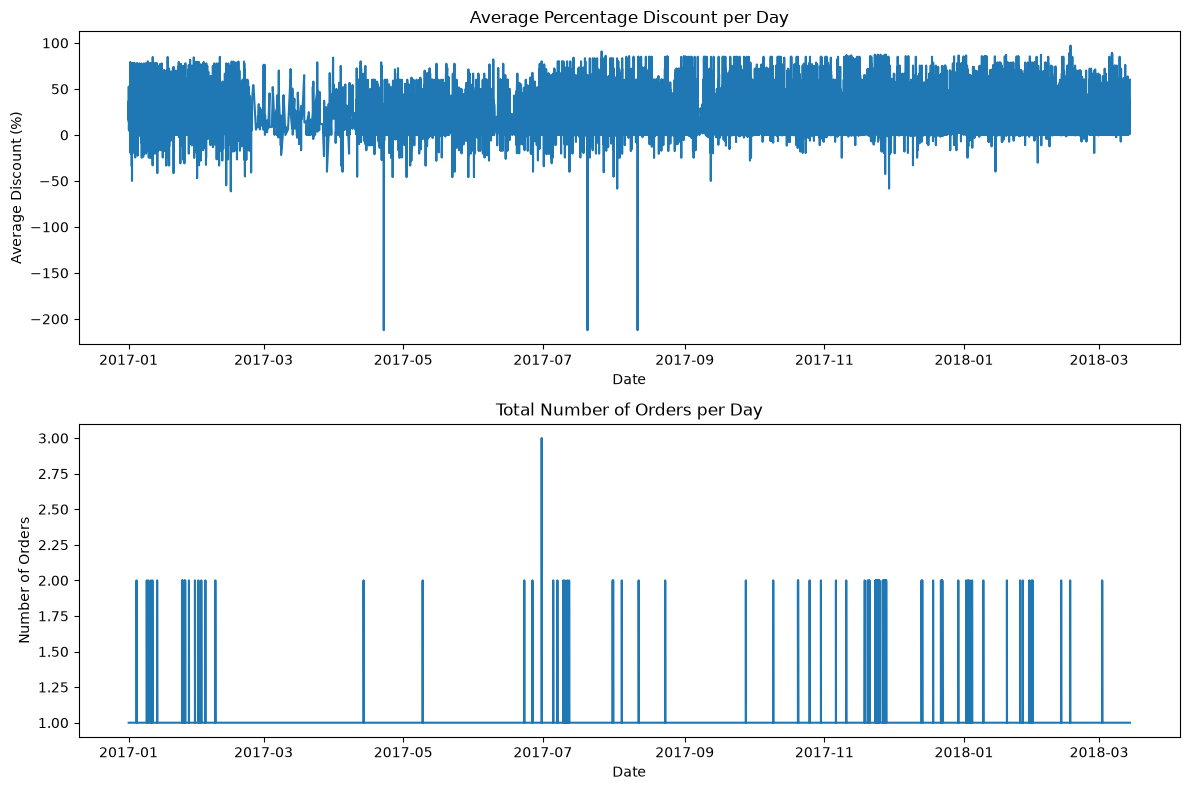

In [51]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Plot 1: Average percentage discount
sns.lineplot(
    data=daily_data,
    x="date",
    y="avg_percentage_discount",
    ax=axes[0]
)

axes[0].set_title("Average Percentage Discount per Day")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Average Discount (%)")


# Plot 2: Total number of orders
sns.lineplot(
    data=daily_data,
    x="date",
    y="total_orders",
    ax=axes[1]
)

axes[1].set_title("Total Number of Orders per Day")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Number of Orders")

plt.tight_layout()
plt.show()

#### Demo: How to overlay two lines with different y axes (this will be shown during solutions)

In [52]:
product_category_df = products_cl.copy()

In [53]:
# Create hierarchy columns
product_category_df["main_category"] = "Other Products"
product_category_df["sub_category"] = "Uncategorized"


# 1. Mobile Devices
product_category_df.loc[
    product_category_df["name"].str.contains("iphone", case=False, na=False),
    ["main_category", "sub_category"]
] = ["Mobile Devices", "Smartphones"]

product_category_df.loc[
    product_category_df["name"].str.contains("ipad|tablet", case=False, na=False),
    ["main_category", "sub_category"]
] = ["Mobile Devices", "Tablets"]

product_category_df.loc[
    product_category_df["name"].str.contains("ipod", case=False, na=False),
    ["main_category", "sub_category"]
] = ["Mobile Devices", "iPod"]


# 2. Computers
product_category_df.loc[
    product_category_df["name"].str.contains("macbook", case=False, na=False),
    ["main_category", "sub_category"]
] = ["Computers", "Laptops"]

product_category_df.loc[
    product_category_df["name"].str.contains("imac|mac mini|mac pro", case=False, na=False),
    ["main_category", "sub_category"]
] = ["Computers", "Desktops"]

product_category_df.loc[
    product_category_df["desc"].str.contains("ram", case=False, na=False),
    ["main_category", "sub_category"]
] = ["Computers", "Components"]


# 3. Storage
product_category_df.loc[
    product_category_df["desc"].str.contains(
        "ssd|hard drive|hard disk|flash drive|memory|storage",
        case=False, na=False
    ),
    ["main_category", "sub_category"]
] = ["Storage", "SSD & Drives"]


# 4. Accessories
product_category_df.loc[
    product_category_df["desc"].str.contains(
        "keyboard|mouse|trackpad",
        case=False, na=False
    ),
    ["main_category", "sub_category"]
] = ["Accessories", "Keyboard & Mouse"]

product_category_df.loc[
    product_category_df["desc"].str.contains(
        "cable|connector|adapter",
        case=False, na=False
    ),
    ["main_category", "sub_category"]
] = ["Accessories", "Cables & Adapters"]

product_category_df.loc[
    product_category_df["desc"].str.contains(
        "charger|dock|hub",
        case=False, na=False
    ),
    ["main_category", "sub_category"]
] = ["Accessories", "Chargers & Docks"]


# 5. Protection
product_category_df.loc[
    product_category_df["desc"].str.contains(
        "case|cover|housing|casing|sleeve|shell|protect",
        case=False, na=False
    ),
    ["main_category", "sub_category"]
] = ["Protection", "Cases & Covers"]


# 6. Audio
product_category_df.loc[
    product_category_df["desc"].str.contains(
        "headset|headphones",
        case=False, na=False
    ),
    ["main_category", "sub_category"]
] = ["Audio", "Headphones"]

product_category_df.loc[
    product_category_df["desc"].str.contains(
        "speaker|music system",
        case=False, na=False
    ),
    ["main_category", "sub_category"]
] = ["Audio", "Speakers"]


# 7. Wearables
product_category_df.loc[
    product_category_df["desc"].str.contains(
        "apple watch|smartwatch|smart watch",
        case=False, na=False
    ),
    ["main_category", "sub_category"]
] = ["Wearables", "Smartwatch"]

product_category_df.loc[
    product_category_df["desc"].str.contains(
        "strap|armband|belt|bracelet",
        case=False, na=False
    ),
    ["main_category", "sub_category"]
] = ["Wearables", "Watch Straps"]


# 8. Electronics
product_category_df.loc[
    product_category_df["desc"].str.contains("monitor", case=False, na=False),
    ["main_category", "sub_category"]
] = ["Electronics", "Monitors"]

product_category_df.loc[
    product_category_df["desc"].str.contains("camera", case=False, na=False),
    ["main_category", "sub_category"]
] = ["Electronics", "Cameras"]


# 9. Networking
product_category_df.loc[
    product_category_df["desc"].str.contains(
        "nas|server|raid|synology",
        case=False, na=False
    ),
    ["main_category", "sub_category"]
] = ["Networking", "NAS & Servers"]


# 10. Other Products
product_category_df.loc[
    product_category_df["desc"].str.contains(
        "backpack",
        case=False, na=False
    ),
    ["main_category", "sub_category"]
] = ["Other Products", "Bags"]

product_category_df.loc[
    product_category_df["desc"].str.contains(
        "scale|thermometer",
        case=False, na=False
    ),
    ["main_category", "sub_category"]
] = ["Other Products", "Measurement Devices"]

product_category_df.loc[
    product_category_df["desc"].str.contains(
        "refurbished|reconditioned|like new",
        case=False, na=False
    ),
    ["main_category", "sub_category"]
] = ["Other Products", "Refurbished"]
product_category_df.groupby('main_category')["sub_category"].value_counts()

main_category   sub_category       
Accessories     Cables & Adapters       592
                Chargers & Docks        238
                Keyboard & Mouse         66
Audio           Speakers                165
                Headphones              150
Computers       Components              669
                Laptops                 158
                Desktops                137
Electronics     Monitors                275
                Cameras                 115
Mobile Devices  Smartphones             460
                Tablets                 362
                iPod                     64
Networking      NAS & Servers          1044
Other Products  Uncategorized           963
                Refurbished             519
                Measurement Devices      89
                Bags                     57
Protection      Cases & Covers         1890
Storage         SSD & Drives           1543
Wearables       Watch Straps            249
                Smartwatch              

In [54]:
orderlines_expanded

,id,id_order,product_id,product_quantity,sku,unit_price,date,name,desc,price,in_stock,type,brand,revenue,discount,total_discount,percentage_discount,month
0,1119116,299545,0,1,OWC0100,47.49,2017-01-01 01:46:16,OWC In-line Digital Temperature Sensor Kit HDD...,Kit temperature sensor for HDD iMac 21 inch an...,60.99,1,12755395,OWC,47.49,13.50,13.50,22.134776,2017-01
1,1119119,299546,0,1,IOT0014,18.99,2017-01-01 01:50:34,iOttie Easy View 2 Car Black Support,IPhone car holder 7 plus / 7/6 Plus / 6 / 5s /...,22.95,0,5720,iOttie,18.99,3.96,3.96,17.254902,2017-01
2,1119120,295347,0,1,APP0700,72.19,2017-01-01 01:54:11,Apple 85W MagSafe 2 charger MacBook Pro screen...,Apple MagSafe 2 Charger for MacBook Pro 15-inc...,89.00,1,13005399,Apple,72.19,16.81,16.81,18.887640,2017-01
3,1119134,299556,0,1,CRU0039-A,60.90,2017-01-01 02:20:14,(Open) Crucial 240GB SSD 7mm BX200,SSD hard drive and high-speed performance with...,76.99,0,1298,Crucial,60.90,16.09,16.09,20.898818,2017-01
4,1119145,299561,0,1,PEB0015,142.49,2017-01-01 02:38:50,Pebble Smartwatch Time Steel Black,Bluetooth Smart Watch with steel case leather ...,299.99,0,11905404,Pebble,142.49,157.50,157.50,52.501750,2017-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53190,1649447,527035,0,1,APP0698,9.99,2018-03-14 11:42:41,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1,1230,Apple,9.99,15.01,15.01,60.040000,2018-03
53191,1649512,527070,0,2,APP0698,9.99,2018-03-14 11:49:01,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1,1230,Apple,19.98,15.01,30.02,60.040000,2018-03
53192,1649522,527074,0,2,APP0698,9.99,2018-03-14 11:49:36,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1,1230,Apple,19.98,15.01,30.02,60.040000,2018-03
53193,1649565,527096,0,3,APP0698,9.99,2018-03-14 11:54:35,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1,1230,Apple,29.97,15.01,45.03,60.040000,2018-03


In [55]:

orderlines_expanded = (
    orderlines_qu
    .merge(product_category_df, on='sku')
    .merge(brands_cl, on='short')
    .rename(columns={'long': 'brand'})
    .drop(columns=['short'])
)

In [56]:
# Creating composite columns
orderlines_expanded['revenue'] = (
    orderlines_expanded['unit_price'] * orderlines_expanded['product_quantity']
)
orderlines_expanded['discount'] = (
    orderlines_expanded['price'] - orderlines_expanded['unit_price']
)
orderlines_expanded['total_discount'] = (
    orderlines_expanded['discount'] * orderlines_expanded['product_quantity']
)
orderlines_expanded['percentage_discount'] = (
    100 * orderlines_expanded['discount'] / orderlines_expanded['price']
)

In [57]:
orderlines_expanded.info()

<class 'pandas.DataFrame'>
RangeIndex: 53195 entries, 0 to 53194
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   id                   53195 non-null  int64         
 1   id_order             53195 non-null  int64         
 2   product_id           53195 non-null  int64         
 3   product_quantity     53195 non-null  int64         
 4   sku                  53195 non-null  str           
 5   unit_price           53195 non-null  float64       
 6   date                 53195 non-null  datetime64[us]
 7   name                 53195 non-null  str           
 8   desc                 53195 non-null  str           
 9   price                53195 non-null  float64       
 10  in_stock             53195 non-null  int64         
 11  type                 53184 non-null  str           
 12  main_category        53195 non-null  str           
 13  sub_category         53195 non-null  str  

In [58]:
discount_by_category = (
    orderlines_expanded
    .groupby("main_category")["percentage_discount"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

discount_by_category

,main_category,percentage_discount
0,Protection,31.080070
1,Audio,26.890901
2,Accessories,24.211628
3,Other Products,22.730249
4,Wearables,20.770887
5,Electronics,19.940873
6,Storage,17.824895
7,Computers,16.372706
8,Mobile Devices,14.449536
9,Networking,13.213908


In [59]:
discount_by_category = (
    orderlines_expanded
    .groupby("main_category")["percentage_discount"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

discount_by_category

,main_category,percentage_discount
0,Protection,31.080070
1,Audio,26.890901
2,Accessories,24.211628
3,Other Products,22.730249
4,Wearables,20.770887
5,Electronics,19.940873
6,Storage,17.824895
7,Computers,16.372706
8,Mobile Devices,14.449536
9,Networking,13.213908


In [60]:
high_discount = orderlines_expanded[
    orderlines_expanded['percentage_discount'] > 80
]

high_discount_count = len(high_discount)

print(f"Number of order lines with more than 80% discount: {high_discount_count}")

Number of order lines with more than 80% discount: 335


In [61]:
category_discount = (
    orderlines_expanded
    .groupby('main_category')
    .agg(
        avg_discount=('percentage_discount', 'mean'),
        total_discount=('total_discount', 'sum'),
        number_of_orders=('id_order', 'count')
    )
    .sort_values('avg_discount', ascending=False)
)

category_discount

,avg_discount,total_discount,number_of_orders
main_category,,,
Protection,31.080070,129317.15,7465
Audio,26.890901,93172.00,2924
Accessories,24.211628,119820.30,8433
Other Products,22.730249,261721.99,7739
Wearables,20.770887,39746.14,2174
Electronics,19.940873,154613.70,2245
Storage,17.824895,306048.21,8540
Computers,16.372706,121720.62,5036
Mobile Devices,14.449536,183106.09,6343


In [62]:
orders_qu["quarter"] = orders_qu["created_date"].dt.to_period("Q")
orders_qu["quarter"]

0        2017Q4
1        2017Q4
2        2017Q1
3        2017Q2
4        2017Q1
          ...  
40980    2018Q1
40981    2018Q1
40982    2018Q1
40983    2018Q1
40984    2018Q1
Name: quarter, Length: 40985, dtype: period[Q-DEC]

In [63]:
total_revenue = orderlines_expanded['revenue'].sum()
print(f"Total Revenue: €{total_revenue:,.2f}")

Total Revenue: €7,811,609.29


In [64]:
total_discount = orderlines_expanded['total_discount'].sum()

print(f"Total Discount Given: €{total_discount:,.2f}")

Total Discount Given: €1,524,159.00


In [66]:
total_products = products_cl["sku"].nunique()

In [67]:
discounted_products = orderlines_expanded.loc[
    orderlines_expanded["discount"] > 0,
    "sku"
].nunique()

In [68]:
non_discounted_products = total_products - discounted_products

print("Products never discounted:", non_discounted_products)

Products never discounted: 5104


In [69]:
total_products = products_cl["sku"].nunique()

In [70]:
discounted_products = orderlines_expanded.loc[
    orderlines_expanded["discount"] > 0,
    "sku"
].nunique()

In [71]:
non_discounted_products = total_products - discounted_products

print("Products never discounted:", non_discounted_products)

Products never discounted: 5104


In [72]:
total_orders = orders_qu['order_id'].nunique()

print(f"Total Orders: {total_orders:,}")

Total Orders: 40,985


In [73]:
total_products = orderlines_expanded['sku'].nunique()

# Unique products that had a discount
discounted_products = (orderlines_expanded[orderlines_expanded['percentage_discount'] > 0]['sku'].nunique())

# Percentage of products discounted
percentage_discounted_products = (
    discounted_products / total_products
) * 100


print(f"Total products sold: {total_products:,}")
print(f"Products discounted : {discounted_products:,}")
print(f"Percentage of products discounted: {percentage_discounted_products:.1f}%")

Total products sold: 5,079
Products discounted : 4,888
Percentage of products discounted: 96.2%


In [74]:
# Only consider discounted products
discounted_sales = orderlines_expanded[
    orderlines_expanded['percentage_discount'] > 0
]

average_discount = discounted_sales['percentage_discount'].mean()
median_discount = discounted_sales['percentage_discount'].median()

print(f"Average discount: {average_discount:.1f}%")
print(f"Median discount: {median_discount:.1f}%")

Average discount: 23.2%
Median discount: 19.6%


In [75]:
discount_bins = pd.cut(
    discounted_sales['percentage_discount'],
    bins=[0,10,20,30,50,100],
    labels=[
        '0-10%',
        '10-20%',
        '20-30%',
        '30-50%',
        '50%+'
    ]
)

discount_distribution = (
    discount_bins
    .value_counts()
    .sort_index()
)

discount_distribution

percentage_discount
0-10%     10497
10-20%    15172
20-30%    11424
30-50%     7303
50%+       4973
Name: count, dtype: int64

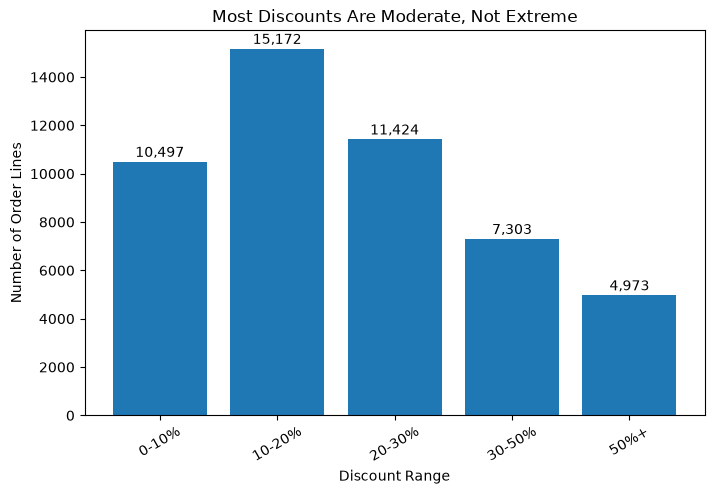

In [76]:
plt.figure(figsize=(8,5))

plt.bar(
    discount_distribution.index,
    discount_distribution.values
)

plt.xlabel("Discount Range")
plt.ylabel("Number of Order Lines")
plt.title("Most Discounts Are Moderate, Not Extreme")

for i, value in enumerate(discount_distribution.values):
    plt.text(
        i,
        value + 200,
        f"{value:,}",
        ha='center'
    )

plt.xticks(rotation=30)
plt.show()

In [78]:
df = orderlines_expanded.copy()

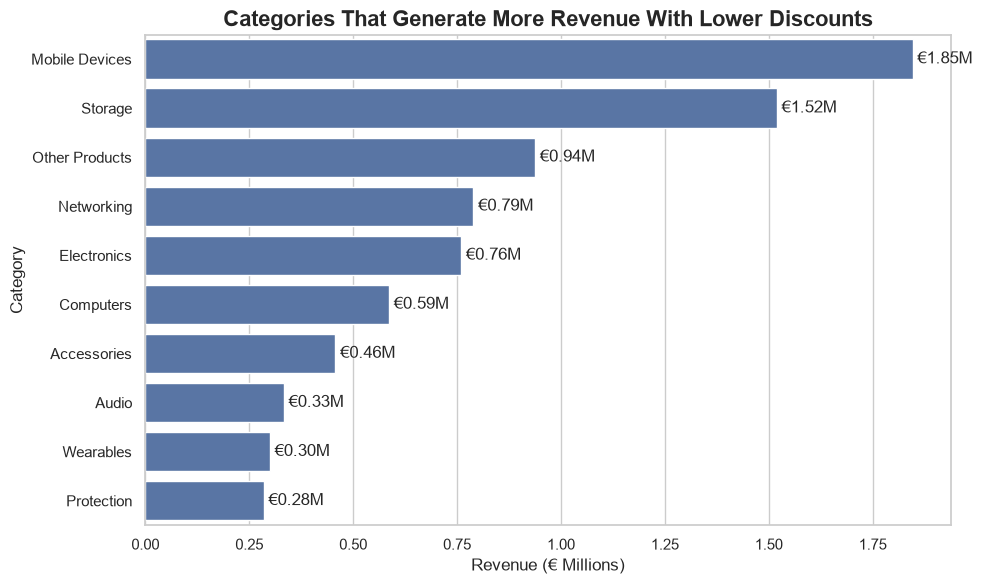

,revenue_formatted,discount_formatted
main_category,,
Mobile Devices,€1.85M,14.4%
Storage,€1.52M,17.8%
Other Products,€0.94M,22.7%
Networking,€0.79M,13.2%
Electronics,€0.76M,19.9%
Computers,€0.59M,16.4%
Accessories,€0.46M,24.2%
Audio,€0.33M,26.9%
Wearables,€0.30M,20.8%


In [81]:
# Group by category
stats = (
    df.groupby("main_category")
    .agg(
        revenue=("revenue", "sum"),
        avg_discount=("percentage_discount", "mean")
    )
    .sort_values("revenue", ascending=False)
)

# Format values
stats["revenue_formatted"] = stats["revenue"].apply(
    lambda x: f"€{x/1e6:.2f}M"
)

stats["discount_formatted"] = stats["avg_discount"].apply(
    lambda x: f"{x:.1f}%"
)

# Reset index for seaborn
plot_df = stats.reset_index()

# Plot
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

sns.barplot(
    data=plot_df,
    x=plot_df["revenue"] / 1e6,
    y="main_category"
)

plt.title(
    "Categories That Generate More Revenue With Lower Discounts",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Revenue (€ Millions)")
plt.ylabel("Category")

# Add revenue labels
for i, row in plot_df.iterrows():
    plt.text(
        row["revenue"] / 1e6,
        i,
        f" €{row['revenue']/1e6:.2f}M",
        va="center"
    )

plt.tight_layout()
plt.show()

# Display summary table
stats[["revenue_formatted", "discount_formatted"]]

In [82]:
df = orderlines_expanded.copy()

In [83]:
# Merge orders information to get created_date
orderlines_expanded = orderlines_expanded.merge(
    orders_qu[['order_id', 'created_date']],
    left_on='id_order',
    right_on='order_id',
    how='left'
)

# Convert date column
orderlines_expanded['created_date'] = pd.to_datetime(
    orderlines_expanded['created_date']
)


# Monthly summary
monthly_summary = (
    orderlines_expanded
    .groupby(orderlines_expanded['created_date'].dt.to_period('M'))
    .agg(
        total_revenue=('revenue', 'sum'),
        average_orderline_revenue=('revenue', 'mean'),
        average_discount=('percentage_discount', 'mean'),
        total_order_lines=('id_order', 'count'),
        total_orders=('id_order', 'nunique')
    )
)

# Convert month format
monthly_summary.index = monthly_summary.index.astype(str)

monthly_summary.round(2)

,total_revenue,average_orderline_revenue,average_discount,total_order_lines,total_orders
created_date,,,,,
2017-01,603656.91,100.56,24.87,6003,4592
2017-02,332473.45,128.02,19.51,2597,2042
2017-03,24856.02,115.61,19.05,215,163
2017-04,227815.87,121.57,18.27,1874,1459
2017-05,331214.98,154.20,15.40,2148,1651
2017-06,286575.67,165.36,17.16,1733,1329
2017-07,598824.97,144.89,24.99,4133,3070
2017-08,379360.33,140.45,20.50,2701,2097
2017-09,387942.85,156.68,20.02,2476,1880


In [84]:
# Convert date column
orderlines_expanded['created_date'] = pd.to_datetime(
    orderlines_expanded['created_date']
)

# Monthly analysis
monthly_discount_analysis = (
    orderlines_expanded
    .groupby(orderlines_expanded['created_date'].dt.to_period('M'))
    .agg(
        total_revenue=('revenue', 'sum'),
        total_discount_given=('total_discount', 'sum'),
        average_discount=('percentage_discount', 'mean'),
        total_orders=('id_order', 'nunique')
    )
)

# Convert month format
monthly_discount_analysis.index = (
    monthly_discount_analysis.index.astype(str)
)

# Round values
monthly_discount_analysis = monthly_discount_analysis.round(2)

monthly_discount_analysis

,total_revenue,total_discount_given,average_discount,total_orders
created_date,,,,
2017-01,603656.91,143873.42,24.87,4592
2017-02,332473.45,58916.22,19.51,2042
2017-03,24856.02,3524.70,19.05,163
2017-04,227815.87,37607.84,18.27,1459
2017-05,331214.98,48068.82,15.40,1651
2017-06,286575.67,48815.26,17.16,1329
2017-07,598824.97,131682.88,24.99,3070
2017-08,379360.33,80974.99,20.50,2097
2017-09,387942.85,69491.73,20.02,1880


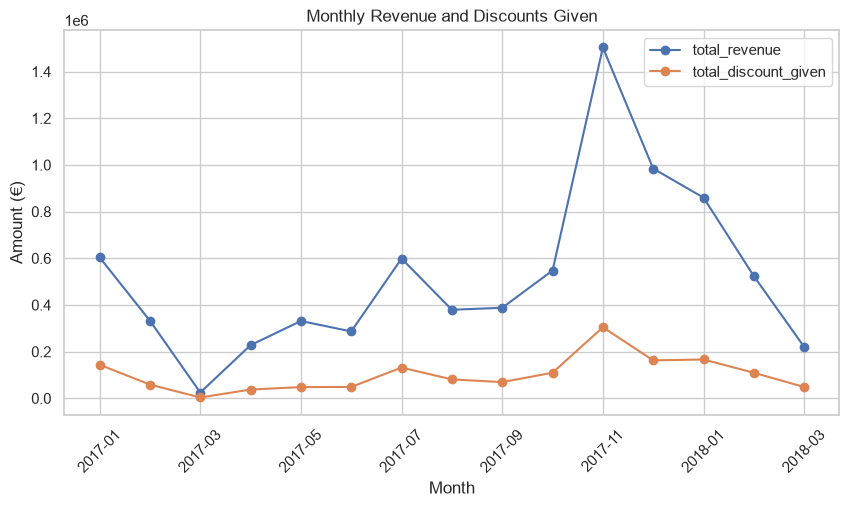

In [85]:
monthly_discount_analysis[['total_revenue',
                           'total_discount_given']].plot(
    figsize=(10,5),
    marker='o'
)

plt.title(
    "Monthly Revenue and Discounts Given"
)

plt.xlabel("Month")
plt.ylabel("Amount (€)")

plt.xticks(rotation=45)

plt.show()

In [86]:
# Create discount buckets
orderlines_expanded['discount_size'] = pd.cut(
    orderlines_expanded['percentage_discount'],
    bins=[-1, 5, 15, 25, 35, float('inf')],
    labels=['0-5%', '5-15%', '15-25%', '25-35%', '35%+']
)

# Calculate number of orders and revenue share by discount size
discount_analysis = (
    orderlines_expanded
    .groupby('discount_size', observed=False)
    .agg(
        number_of_orders=('id_order', 'nunique'),
        revenue=('revenue', 'sum')
    )
    .reset_index()
)

# Calculate percentages
discount_analysis['% of all orders'] = (
    discount_analysis['number_of_orders'] /
    discount_analysis['number_of_orders'].sum() * 100
).round(1)

discount_analysis['% of all revenue'] = (
    discount_analysis['revenue'] /
    discount_analysis['revenue'].sum() * 100
).round(1)

discount_analysis

,discount_size,number_of_orders,revenue,% of all orders,% of all revenue
0,0-5%,6879,1862185.19,14.3,24.6
1,5-15%,12780,2597829.93,26.6,34.4
2,15-25%,12695,1973908.94,26.5,26.1
3,25-35%,7264,753753.85,15.1,10.0
4,35%+,8339,368718.11,17.4,4.9


In [89]:
orderlines_expanded["month"] = pd.to_datetime(
    orderlines_expanded["date"]
).dt.month

In [90]:
orderlines_expanded[["date", "month"]].head()

,date,month
0,2017-01-01 01:46:16,1
1,2017-01-01 01:50:34,1
2,2017-01-01 01:54:11,1
3,2017-01-01 02:20:14,1
4,2017-01-01 02:38:50,1


In [91]:
monthly_avg_df = (
    orderlines_expanded
    .groupby("month")
    .agg(
        total_items=("product_quantity", "sum"),
        total_orders=("id_order", "nunique")
    )
    .reset_index()
)

In [92]:
monthly_avg_df["Month"] = monthly_avg_df["month"].map({
    1: "Jan",
    2: "Feb",
    3: "Mar",
    4: "Apr",
    5: "May",
    6: "Jun",
    7: "Jul",
    8: "Aug",
    9: "Sep",
    10: "Oct",
    11: "Nov",
    12: "Dec"
})

In [95]:
monthly_avg_df["Average Items per Order"] = (
    monthly_avg_df["total_items"] /
    monthly_avg_df["total_orders"]
)

monthly_avg_df

,month,total_items,total_orders,Month,Average Items per Order
0,1,13401,9121,Jan,1.469247
1,2,7060,4966,Feb,1.421667
2,3,2098,1509,Mar,1.390325
3,4,2128,1468,Apr,1.449591
4,5,2573,1661,May,1.549067
5,6,2051,1345,Jun,1.524907
6,7,4621,3080,Jul,1.500325
7,8,3022,2095,Aug,1.442482
8,9,2788,1900,Sep,1.467368
9,10,4015,2766,Oct,1.451555


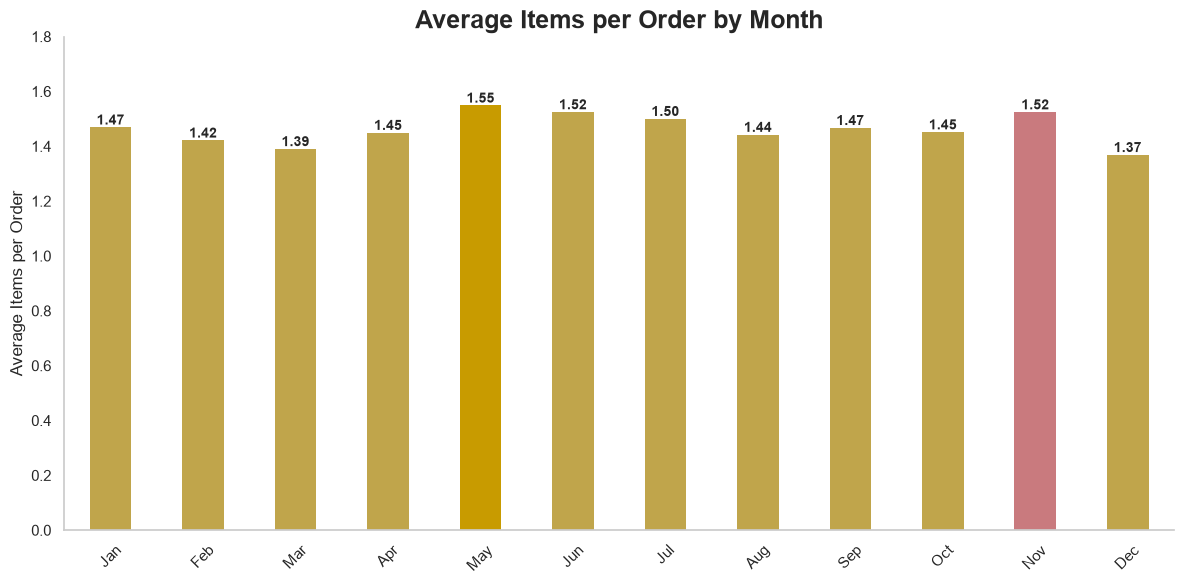

In [96]:
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=monthly_avg_df,
    x="Month",
    y="Average Items per Order",
    color="#D4AF37",
    width=0.45,
    edgecolor="none",
    order=["Jan", "Feb", "Mar", "Apr", "May", "Jun",
           "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
)

# Highlight May
ax.patches[4].set_facecolor("#C89B00")

# Highlight November
ax.patches[10].set_facecolor("#C97A7E")

plt.title(
    "Average Items per Order by Month",
    fontsize=18,
    fontweight="bold"
)

plt.ylabel("Average Items per Order")
plt.xlabel("")
plt.ylim(0, 1.8)
plt.xticks(rotation=45)

sns.despine()
plt.grid(False)

for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{bar.get_height():.2f}",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

In [97]:
most_sold = (
    orderlines_expanded
    .groupby('name', as_index=False)['product_quantity']
    .sum()
    .rename(columns={'product_quantity': 'Units Sold'})
    .sort_values('Units Sold', ascending=False)
)

most_sold.head(10)

,name,Units Sold
1479,IPhone AppleCare Protection Plan,955
217,Apple Lightning Cable Connector to USB 1m Whit...,820
135,AirPods Apple Bluetooth Headset for iPhone iPa...,537
1075,EarPods Apple Headphones with Remote and Mic (...,489
3709,"Red 4TB WD 35 ""Mac PC hard drive and NAS",476
3756,Samsung 850 EVO SSD Disk 500GB,329
897,Crucial MX300 525GB SSD Disk,328
456,Apple iPhone 6 32GB Space Gray,270
88,"AdaptaDrive NewerTech adapter 2.5 ""to 3.5"" SATA",252
893,Crucial MX300 275GB SSD Disk,248


In [98]:
top_brands = (
    orderlines_expanded
    .groupby('brand')['product_quantity']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

top_brands.head(10)

,brand,product_quantity
0,Apple,11156
1,OWC,3857
2,Western Digital,2404
3,Belkin,2279
4,LaCie,2130
5,Crucial,2070
6,Satechi,1824
7,Wacom,1816
8,Pack,1710
9,NewerTech,1648


In [99]:
top_revenue = (
    orderlines_expanded
    .groupby('name')['revenue']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

top_revenue.head(10)

,name,revenue
0,"LG 27UD88-W Monitor 27 ""UHD 4K USB 3.0 USB-C",135375.83
1,Apple iPhone 6 32GB Space Gray,104560.64
2,AirPods Apple Bluetooth Headset for iPhone iPa...,86473.26
3,Apple iPhone 64GB Space Gray 8,85301.93
4,Apple iPhone 32GB Space Gray,80715.76
5,"Apple MacBook Air 13 ""Core i5 18GHz | 8GB RAM ...",74964.06
6,Apple iPhone 8 Plus 64GB Gold,70721.79
7,"Red 4TB WD 35 ""Mac PC hard drive and NAS",65589.96
8,Apple iPhone 8 Plus 64GB Space Gray,60090.08
9,Apple iPhone 64GB Gold 8,52981.19
